## drop down GeoPandas test

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import geopandas as gpd

import ipywidgets as widgets
from IPython.display import display, clear_output

In [11]:
usa_gdf = gpd.read_file('F:/Libraries/My Documents/UM/Capstone/s_18mr25.shp')
usa_gdf = usa_gdf.drop([2, 10, 36, 43, 51, 53, 54, 55, 56, 58])

In [12]:
snowman_df = pd.read_csv("F:/Libraries/My Documents/UM/Capstone/SnowmanData_actual_2024_20s.csv")
snowman_gdf = gpd.GeoDataFrame(snowman_df, geometry=gpd.points_from_xy(snowman_df.LONGITUDE, snowman_df.LATITUDE), crs='epsg:4326')
usa_gdf = usa_gdf.to_crs('epsg:3395')
snowman_gdf = snowman_gdf.to_crs('epsg:3395')
snowman_gdf['geometry'] = snowman_gdf.buffer(50000)

In [13]:
# Function to plot data for a selected date
def plot_date(selected_date):
    fig, ax = plt.subplots(figsize=(50,50))
    ax.set_title('Where Can I Build a Snowman? ' + selected_date, fontdict={'fontsize': '64'})
    tmp_gdf = snowman_gdf[snowman_gdf['DATE'] == selected_date]
    snowman_no_gdf = tmp_gdf[snowman_gdf['SNOWMAN'] == 0]
    snowman_yes_gdf = tmp_gdf[snowman_gdf['SNOWMAN'] == 1]
    snowman_no_gdf.plot(ax=ax, color='black')
    snowman_yes_gdf.plot(ax=ax, color='lightblue')
    usa_gdf.plot(ax=ax, color='None', edgecolor='green') 

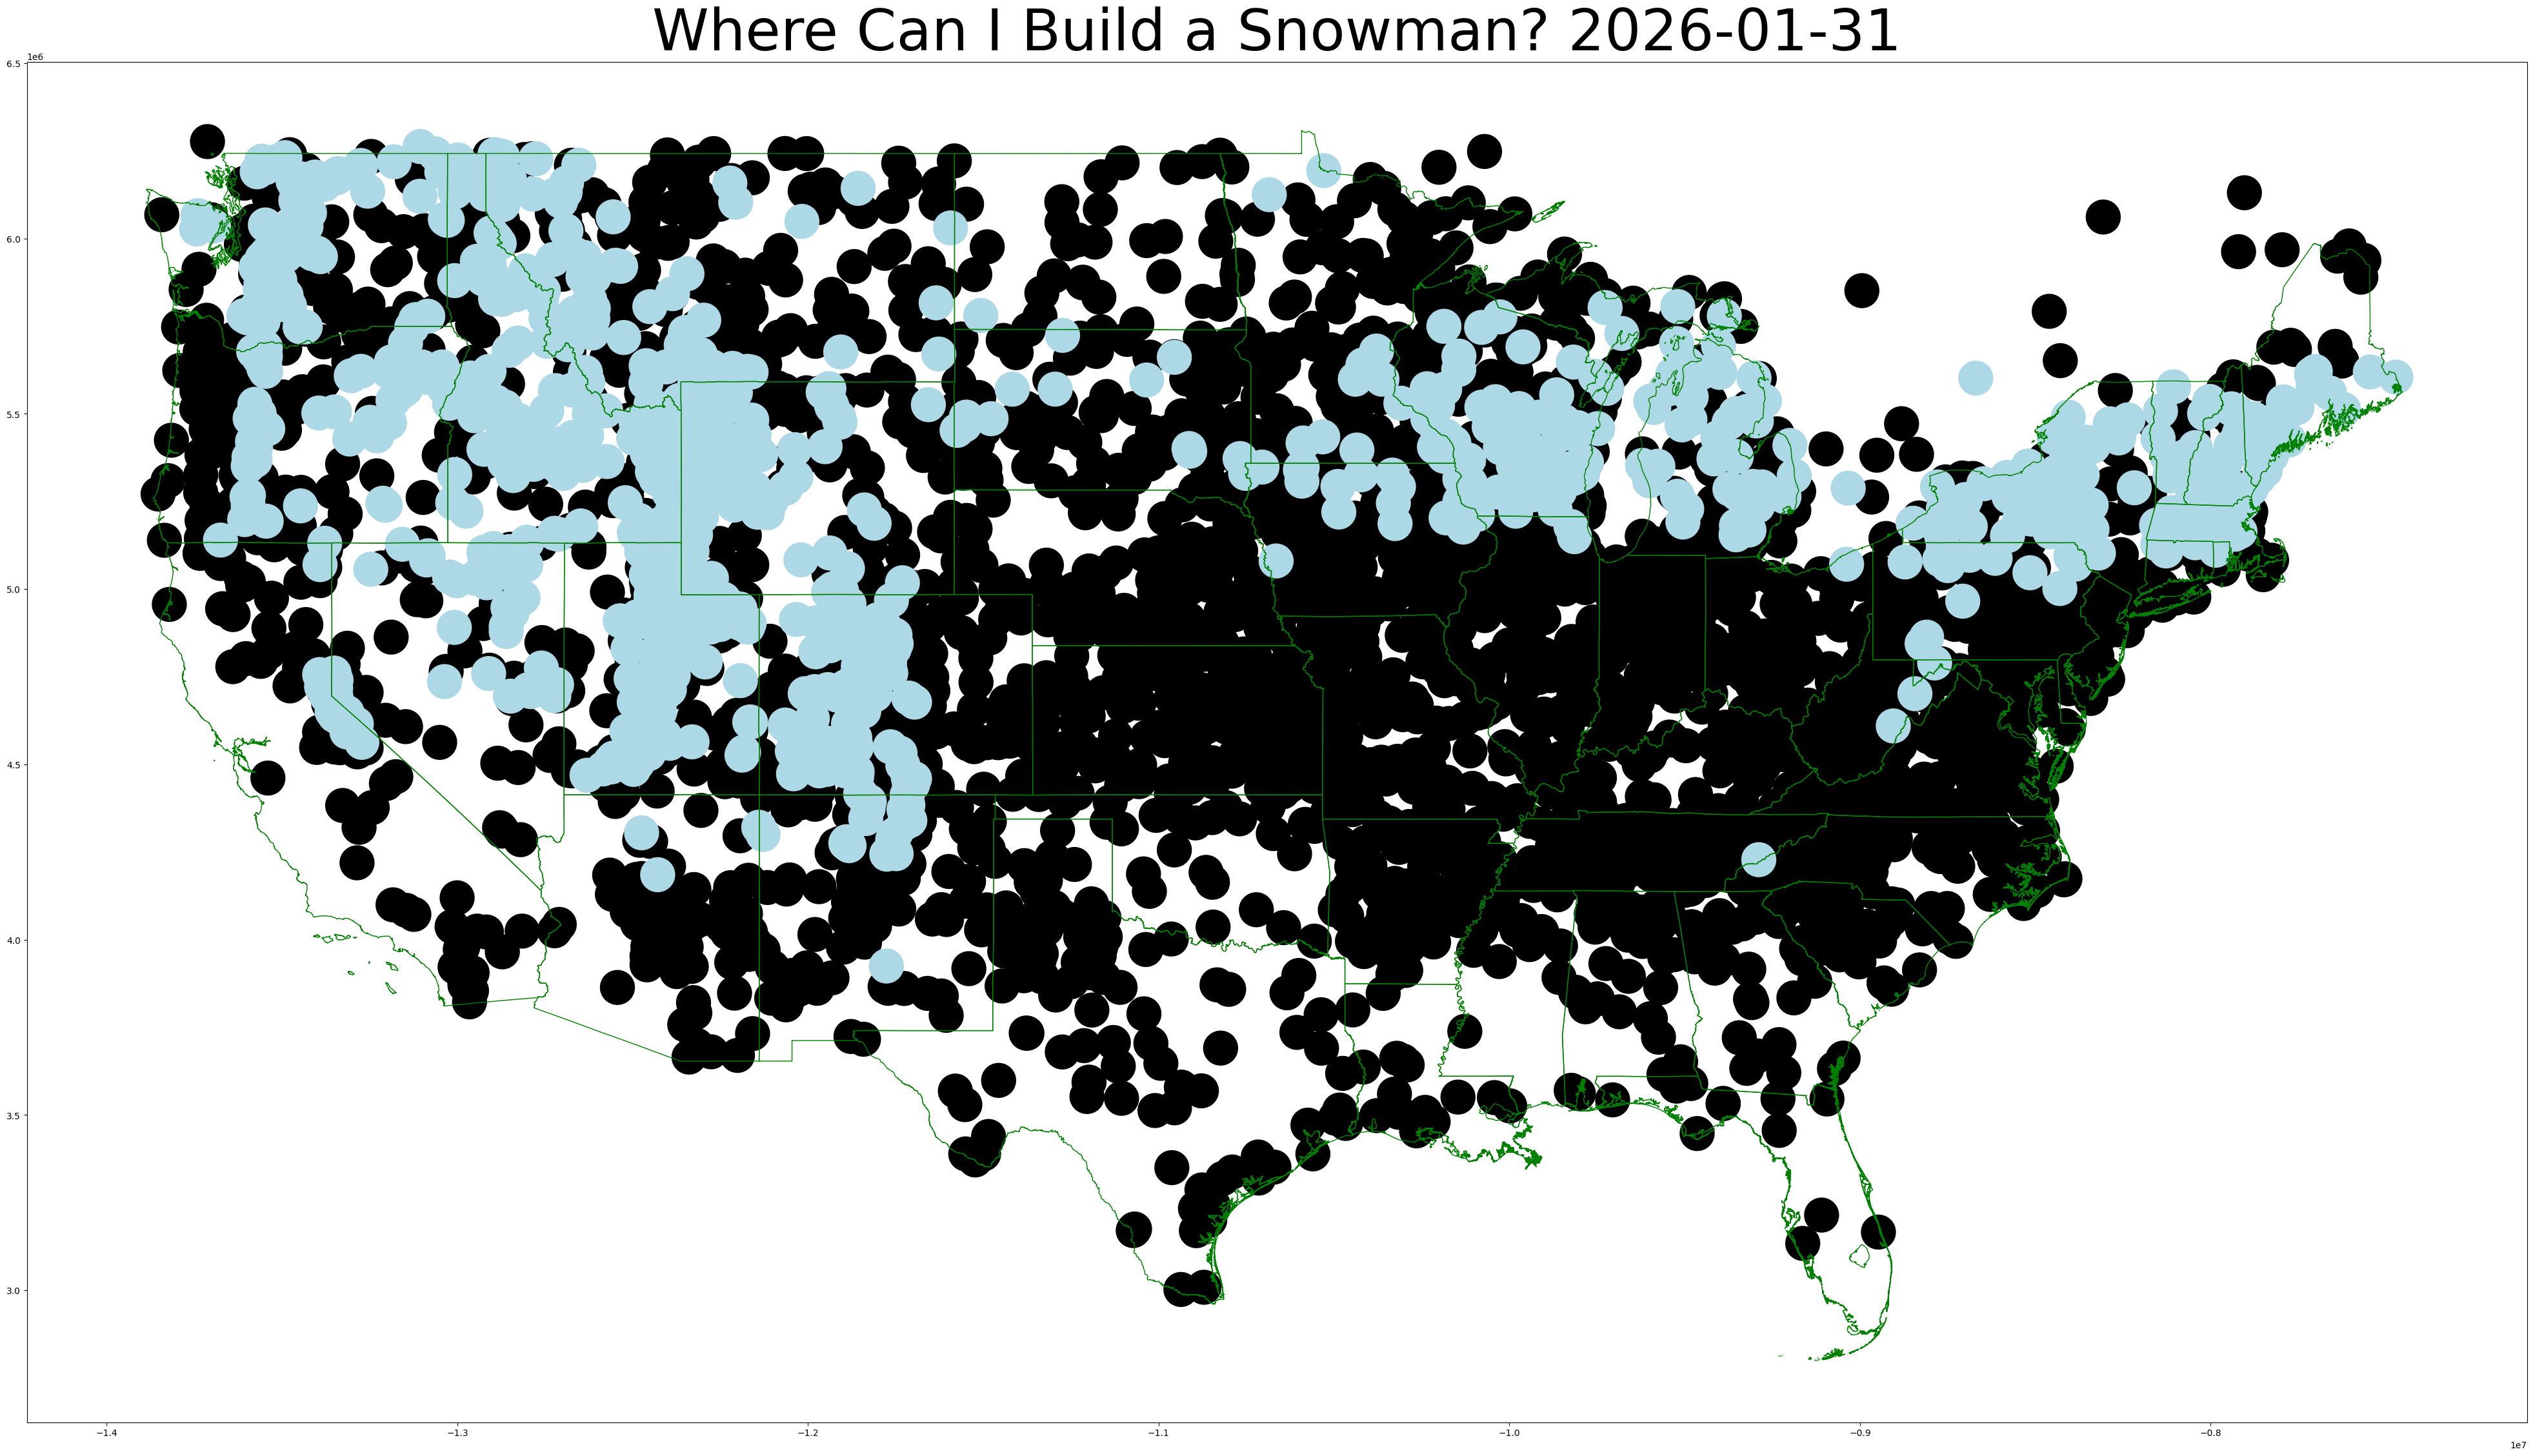

In [14]:

date_picker = widgets.DatePicker(
    description='Pick a Date',
    disabled=False
)

# Function to update plot on dropdown change
def on_date_change(change):
  clear_output()
  plot_date(change['new'].strftime('%Y-%m-%d'))

date_picker.observe(on_date_change, names='value')

In [15]:
# Display the dropdown
display(date_picker)

DatePicker(value=None, description='Pick a Date', step=1)